In [4]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [5]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [6]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [7]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [8]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"], inplace=True)

In [20]:
df.drop(columns="Student_ID",inplace=True)

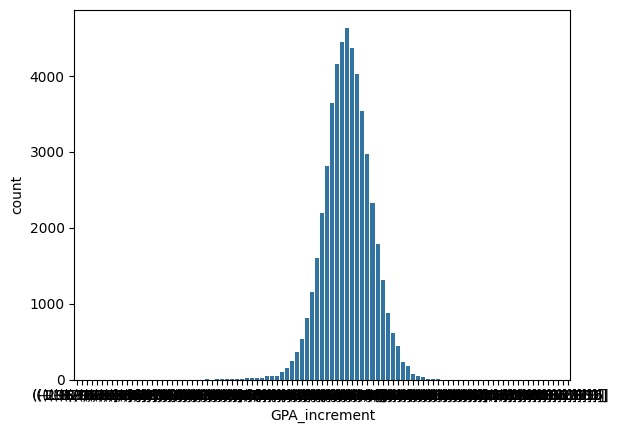

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [16]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [18]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   is_Copywriting/Drafting       50000 non-null  bool   
 10  is_Ideation                   50000 non-null  bool   
 11  is_Summarizing_Reading        50000 non-null  bool   
 12  is_Debugging/Troubleshooting  50000 non-null  bool   
 13  is_Direct_An

In [22]:
for c in df["Primary_Use_Case"].unique():
    df["is_"+c]= df["Primary_Use_Case"]==c

df.drop(columns="Primary_Use_Case",inplace=True)

In [24]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [25]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [27]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [28]:
for c in df["Institutional_Policy"].unique():
    df["is_"+c]= df["Institutional_Policy"]==c

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [30]:
for c in df["Major_Category"].unique():
    df["major_is_"+c]= df["Major_Category"]==c

df.drop(columns="Major_Category",inplace=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor